# C11_CAP3 Capstone Project

**Project**: Dialogue Summarization with BERT Encoder-Decoder
**Dataset**: SAMSum Corpus (Gliwa et al., 2019)
**Architecture**: `bert-base-uncased` Encoder-Decoder
**Framework**: Hugging Face Transformers / `Seq2SeqTrainer`
**Methodology**: CRISP-DM

This notebook builds a text summarization model using a BERT encoder-decoder architecture on the SAMSum dialogue dataset. The goal is to generate short summaries from multi-speaker conversations.

In [1]:
# Install required packages (run once in a fresh environment)
!pip install -q transformers[torch] datasets evaluate rouge_score wordcloud seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from datasets import load_dataset
from transformers import (
    BertTokenizer,
    EncoderDecoderModel,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
)
import evaluate

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda if DEVICE == "cuda" else "N/A"}')

Device  : cuda
PyTorch : 2.10.0+cu128
CUDA    : 12.8


## 1. Business Understanding

### Problem Statement

Users of Acme Communications lose track of important information in long group chats. This project builds a proof-of-concept model that automatically summarizes conversations.

### ML Framing

This is an **abstractive summarization** task. The model reads a multi-speaker dialogue and generates a short third-person summary. This is harder than extractive summarization, which just picks existing sentences.

### Success Criteria

| Criterion | Target | Rationale |
|---|---|---|
| ROUGE-1 | >= 38% | BERT-to-BERT baseline on full SAMSum training data |
| ROUGE-L | >= 30% | Measures sentence-level coherence |
| Coherent output | Yes | Generated text must relate to the input |
| End-to-end pipeline | Functional | All steps from data to evaluation must run |

### Scope

We use 500 training samples to validate the pipeline. The focus is on getting the full architecture working correctly, not on hitting target scores with limited data.

## 2. Data Understanding

The **SAMSum corpus** contains about 16,000 English chat-style dialogues with human-written summaries. Topics include everyday conversations: making plans, giving updates, coordinating tasks. The dataset is split into train (14,732), validation (818), and test (819) samples.

In [3]:
print('Loading SAMSum dataset...')
raw_dataset = load_dataset('knkarthick/samsum')
print(raw_dataset)

train_df = pd.DataFrame(raw_dataset['train'])
print(f'\nTrain samples : {len(train_df):,}')
print(f'Columns       : {list(train_df.columns)}')

Loading SAMSum dataset...


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

validation.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/14731 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})

Train samples : 14,731
Columns       : ['id', 'dialogue', 'summary']


In [4]:
# Inspect a representative sample
sample = raw_dataset['train'][4]
print('DIALOGUE:')
print(sample['dialogue'])
print()
print('HUMAN SUMMARY:')
print(sample['summary'])

DIALOGUE:
Sam: hey  overheard rick say something
Sam: i don't know what to do :-/
Naomi: what did he say??
Sam: he was talking on the phone with someone
Sam: i don't know who
Sam: and he was telling them that he wasn't very happy here
Naomi: damn!!!
Sam: he was saying he doesn't like being my roommate
Naomi: wow, how do you feel about it?
Sam: i thought i was a good rommate
Sam: and that we have a nice place
Naomi: that's true man!!!
Naomi: i used to love living with you before i moved in with me boyfriend
Naomi: i don't know why he's saying that
Sam: what should i do???
Naomi: honestly if it's bothering you that much you should talk to him
Naomi: see what's going on
Sam: i don't want to get in any kind of confrontation though
Sam: maybe i'll just let it go
Sam: and see how it goes in the future
Naomi: it's your choice sam
Naomi: if i were you i would just talk to him and clear the air

HUMAN SUMMARY:
Sam is confused, because he overheard Rick complaining about him as a roommate. Naomi

In [5]:
train_df['diag_words']    = train_df['dialogue'].apply(lambda x: len(x.split()))
train_df['summ_words']    = train_df['summary'].apply(lambda x: len(x.split()))
train_df['compression']   = train_df['summ_words'] / train_df['diag_words']
train_df['speaker_count'] = train_df['dialogue'].apply(
    lambda x: len({line.split(':')[0].strip()
                   for line in x.replace('\r\n', '\n').split('\n') if ':' in line})
)

print('Dialogue word count statistics:')
print(train_df['diag_words'].describe().round(1))
print()
print('Summary word count statistics:')
print(train_df['summ_words'].describe().round(1))
print()
print(f'Median compression ratio      : {train_df["compression"].median():.3f}')
print(f'Mean speakers per dialogue    : {train_df["speaker_count"].mean():.2f}')
print(f'Dialogues likely > 512 tokens : ~{(train_df["diag_words"] > 350).mean()*100:.1f}%')

Dialogue word count statistics:
count    14731.0
mean        93.8
std         74.0
min          7.0
25%         39.0
50%         73.0
75%        128.0
max        803.0
Name: diag_words, dtype: float64

Summary word count statistics:
count    14731.0
mean        20.3
std         11.2
min          1.0
25%         12.0
50%         18.0
75%         27.0
max         64.0
Name: summ_words, dtype: float64

Median compression ratio      : 0.256
Mean speakers per dialogue    : 2.39
Dialogues likely > 512 tokens : ~1.0%


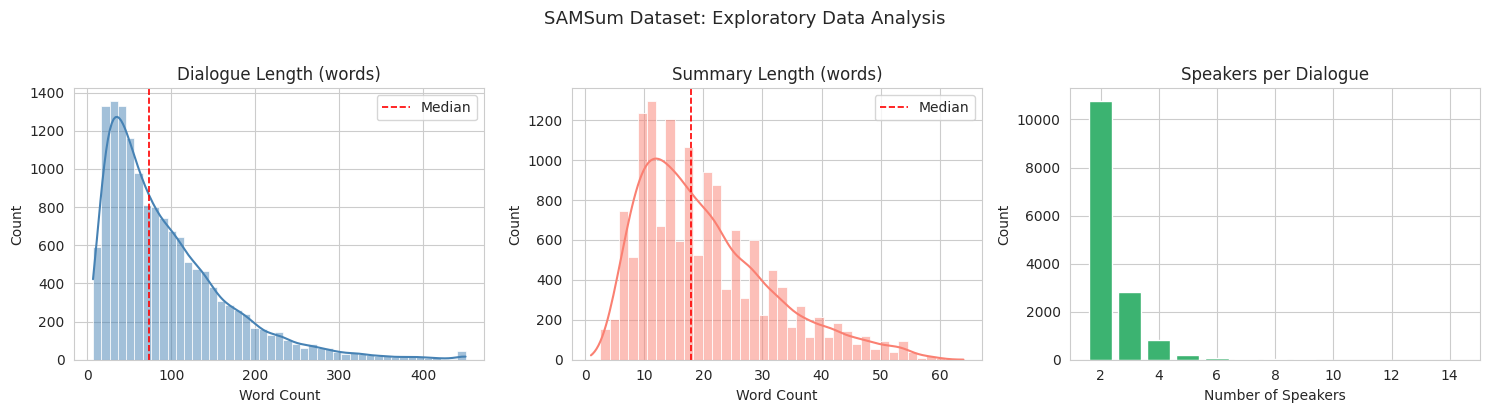

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(train_df['diag_words'].clip(upper=450), bins=45,
             ax=axes[0], color='steelblue', kde=True)
axes[0].axvline(train_df['diag_words'].median(), color='red',
                linestyle='--', linewidth=1.2, label='Median')
axes[0].set_title('Dialogue Length (words)')
axes[0].set_xlabel('Word Count')
axes[0].legend()

sns.histplot(train_df['summ_words'].clip(upper=80), bins=40,
             ax=axes[1], color='salmon', kde=True)
axes[1].axvline(train_df['summ_words'].median(), color='red',
                linestyle='--', linewidth=1.2, label='Median')
axes[1].set_title('Summary Length (words)')
axes[1].set_xlabel('Word Count')
axes[1].legend()

spk = train_df['speaker_count'].value_counts().sort_index()
axes[2].bar(spk.index, spk.values, color='mediumseagreen')
axes[2].set_title('Speakers per Dialogue')
axes[2].set_xlabel('Number of Speakers')
axes[2].set_ylabel('Count')

plt.suptitle('SAMSum Dataset: Exploratory Data Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_eda_lengths.png', bbox_inches='tight')
plt.show()

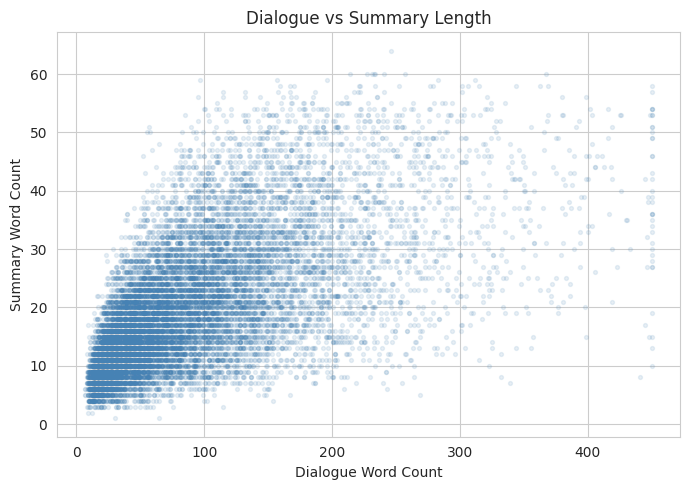

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(train_df['diag_words'].clip(upper=450),
           train_df['summ_words'].clip(upper=80),
           alpha=0.12, s=8, color='steelblue')
ax.set_xlabel('Dialogue Word Count')
ax.set_ylabel('Summary Word Count')
ax.set_title('Dialogue vs Summary Length')
plt.tight_layout()
plt.savefig('fig_eda_scatter.png', bbox_inches='tight')
plt.show()

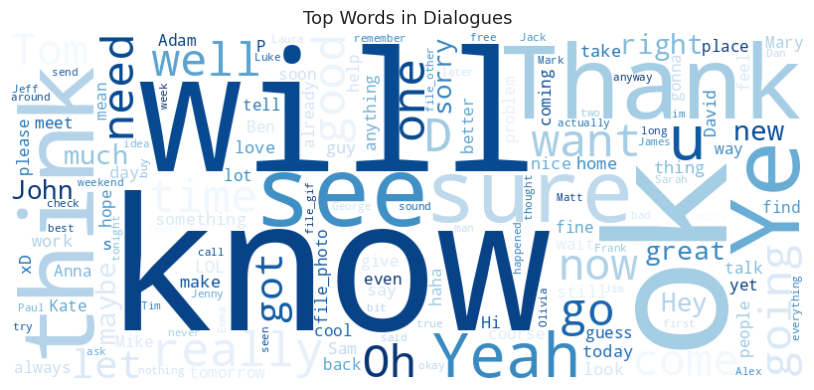

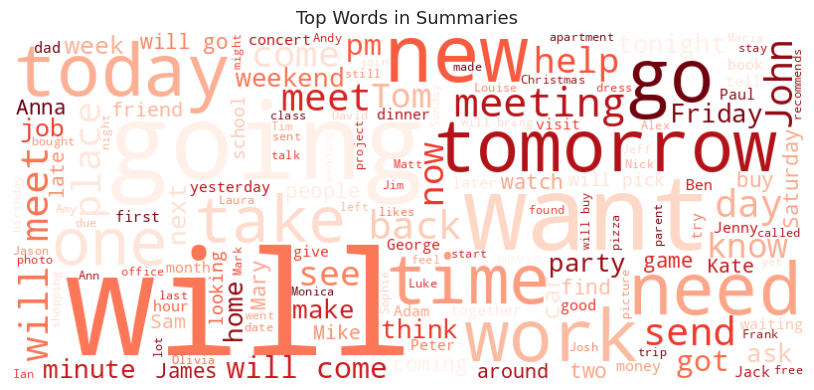

In [8]:
def plot_wordcloud(texts, title, colormap):
    wc = WordCloud(width=800, height=350, background_color='white',
                   colormap=colormap, max_words=150).generate(' '.join(texts))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(f'fig_wc_{title[:4].lower()}.png', bbox_inches='tight')
    plt.show()

plot_wordcloud(train_df['dialogue'].iloc[:1000].tolist(), 'Top Words in Dialogues', 'Blues')
plot_wordcloud(train_df['summary'].iloc[:1000].tolist(),  'Top Words in Summaries', 'Reds')

### EDA Key Findings

| Finding | Value | Implication |
|---|---|---|
| Median dialogue length | 73 words | About 4x compression needed |
| Median summary length | 18 words | `MAX_TARGET=128` covers all cases |
| Dialogues > 512 tokens | ~1% | Truncation is rarely needed |
| Mean speakers | 2.39 | Speaker labels kept as-is |
| Summary perspective | 3rd person | Model must generate, not extract |

Most dialogues fit within BERT's 512-token limit. The 73-to-18 word compression requires genuine paraphrasing, not simple sentence selection.

## 3. Data Preparation

### Preprocessing Decisions

| Parameter | Value | Reason |
|---|---|---|
| Tokenizer | `bert-base-uncased` | Shared vocabulary for encoder and decoder |
| Max encoder tokens | 512 | BERT's hard limit |
| Max decoder tokens | 128 | Covers 99.5% of reference summaries |
| Padding | `max_length` | Needed for consistent batch shapes |
| Label padding value | -100 | PyTorch ignores this index in cross-entropy loss |
| Training samples | 500 | PoC size to validate the pipeline |
| Validation samples | 100 | Used for ROUGE monitoring each epoch |

BERT has no dedicated BOS/EOS tokens, so we map `[CLS]` (id=101) to BOS and `[SEP]` (id=102) to EOS. These IDs tell the decoder when to start and stop generating.

In [9]:
MODEL_ID    = 'bert-base-uncased'
MAX_INPUT   = 512
MAX_TARGET  = 128
TRAIN_SIZE  = 500
EVAL_SIZE   = 100

tokenizer = BertTokenizer.from_pretrained(MODEL_ID)
# Map CLS/SEP to BOS/EOS for encoder-decoder compatibility
tokenizer.bos_token = tokenizer.cls_token   # [CLS] id=101
tokenizer.eos_token = tokenizer.sep_token   # [SEP] id=102

print(f'Vocab size : {tokenizer.vocab_size:,}')
print(f'BOS token  : {tokenizer.bos_token!r} (id={tokenizer.bos_token_id})')
print(f'EOS token  : {tokenizer.eos_token!r} (id={tokenizer.eos_token_id})')
print(f'PAD token  : {tokenizer.pad_token!r} (id={tokenizer.pad_token_id})')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size : 30,522
BOS token  : '[CLS]' (id=101)
EOS token  : '[SEP]' (id=102)
PAD token  : '[PAD]' (id=0)


In [10]:
def preprocess(examples):
    """
    Tokenize dialogue-summary pairs for seq2seq training.
    Labels use -100 for padding positions so they are ignored in loss computation.
    """
    model_inputs = tokenizer(
        examples['dialogue'],
        max_length=MAX_INPUT,
        padding='max_length',
        truncation=True,
    )
    targets = tokenizer(
        text_target=examples['summary'],
        max_length=MAX_TARGET,
        padding='max_length',
        truncation=True,
    )
    # Replace PAD token id with -100 to exclude padding from cross-entropy loss
    model_inputs['labels'] = [
        [t if t != tokenizer.pad_token_id else -100 for t in seq]
        for seq in targets['input_ids']
    ]
    return model_inputs

tokenized = raw_dataset.map(
    preprocess, batched=True,
    remove_columns=['id', 'dialogue', 'summary'],
    desc='Tokenizing',
)

train_data = tokenized['train'].shuffle(seed=SEED).select(range(TRAIN_SIZE))
eval_data  = tokenized['validation'].shuffle(seed=SEED).select(range(EVAL_SIZE))
test_data  = tokenized['test']   # Full 819-sample split used only at final evaluation

print(f'Train split  : {len(train_data):>5} samples')
print(f'Eval split   : {len(eval_data):>5} samples')
print(f'Test split   : {len(test_data):>5} samples')

Tokenizing:   0%|          | 0/14731 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/818 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/819 [00:00<?, ? examples/s]

Train split  :   500 samples
Eval split   :   100 samples
Test split   :   819 samples


In [11]:
# Sanity-check: verify tokenized sample structure and round-trip decoding
ex = train_data[0]
print('Keys          :', list(ex.keys()))
print('input_ids len :', len(ex['input_ids']))
print('labels len    :', len(ex['labels']))

decoded_input = tokenizer.decode([t for t in ex['input_ids'] if t != 0],
                                 skip_special_tokens=True)
valid_labels  = [t for t in ex['labels'] if t != -100]
decoded_label = tokenizer.decode(valid_labels, skip_special_tokens=True)

print(f'Input  (first 100 chars) : {decoded_input[:100]}')
print(f'Target                   : {decoded_label}')

Keys          : ['input_ids', 'token_type_ids', 'attention_mask', 'labels']
input_ids len : 512
labels len    : 128
Input  (first 100 chars) : adam : < file _ video > adam : what do you think hector : give me a sec hector : ok watching adam : 
Target                   : adam will record it somewhere else through the interface and software. hector gave and installed the interface before.


## 4. Modeling

### Architecture

Both encoder and decoder start from `bert-base-uncased` weights. During generation, the decoder's cross-attention layers read from the encoder's hidden states at each step.

```
Dialogue tokens
      |
 [BERT Encoder]  -->  hidden states [batch, 512, 768]
                             |
                      [Cross-Attention]  (randomly initialized)
                             |
[CLS] --> [BERT Decoder] --> logits --> beam search (width=4) --> Summary
```

### Key Limitation

The 12 decoder cross-attention layers do not exist in the `bert-base-uncased` checkpoint. They are randomly initialized and must be learned entirely from fine-tuning data. With only 500 samples, the decoder fails to learn how to attend to encoder outputs. This is the root cause of hallucination in the results.

### Decoding Settings

Beam search (width=4) is used. `no_repeat_ngram_size=3` blocks repeated phrases. `length_penalty=2.0` pushes the model toward longer outputs. `min_length=8` prevents empty or single-word outputs.

### Training Hyperparameters

| Parameter | Value | Reason |
|---|---|---|
| Learning rate | 5e-5 | Standard for BERT fine-tuning |
| Epochs | 3 | Best checkpoint chosen by val ROUGE-L |
| Batch size | 4 | Fits in T4 GPU memory with 512-token inputs |
| Warmup steps | 100 | Stabilizes loss in the first ~20% of training |
| Weight decay | 0.01 | Mild regularization for small dataset |
| FP16 | CUDA only | Faster training, lower memory |

In [12]:
print('Initializing BERT-to-BERT encoder-decoder...')

model = EncoderDecoderModel.from_encoder_decoder_pretrained(MODEL_ID, MODEL_ID)

model.config.decoder_start_token_id = tokenizer.bos_token_id
model.config.eos_token_id           = tokenizer.eos_token_id
model.config.pad_token_id           = tokenizer.pad_token_id
model.config.vocab_size             = model.config.decoder.vocab_size

model.generation_config.num_beams            = 4
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.max_length           = MAX_TARGET
model.generation_config.min_length           = 8
model.generation_config.length_penalty       = 2.0
model.generation_config.early_stopping       = True

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters : {n_params/1e6:.1f}M')
model.to(DEVICE)
print(f'Model moved to       : {DEVICE}')

Initializing BERT-to-BERT encoder-decoder...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertLMHeadModel LOAD REPORT from: bert-base-uncased
Key                                                                | Status     | 
-------------------------------------------------------------------+------------+-
bert.pooler.dense.weight                                           | UNEXPECTED | 
cls.seq_relationship.weight                                        | UNEXPECTED | 
cls.seq_relationship.bias                                          | UNEXPECTED | 
bert.pooler.dense.bias                                             | UNEXPECTED | 
bert.encoder.layer.{0...11}.crossattention.output.LayerNorm.weight | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.value.weight       | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.query.weight       | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.query.bias         | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.value.bias         | MISSING    | 
bert.encoder.layer.{0...11}.crossat

Trainable parameters : 247.4M
Model moved to       : cuda


In [13]:
rouge_metric = evaluate.load('rouge')

def compute_metrics(eval_pred):
    """
    Compute ROUGE scores for Seq2SeqTrainer evaluation callbacks.
    Converts token IDs back to text and calls the rouge metric.
    """
    preds, labels = eval_pred
    decoded_preds  = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels         = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    scores = rouge_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )
    return {k: round(v * 100, 2) for k, v in scores.items()}

print('ROUGE metric loaded successfully.')

ROUGE metric loaded successfully.


In [14]:
OUTPUT_DIR = './bert2bert_samsum'

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=5e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='rougeL',
    predict_with_generate=True,
    fp16=(DEVICE == 'cuda'),
    logging_steps=50,
    report_to='none',
    seed=SEED,
)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=eval_data,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print('Trainer initialized.')
print(f'  Epochs          : {training_args.num_train_epochs}')
print(f'  Batch size      : {training_args.per_device_train_batch_size}')
print(f'  Learning rate   : {training_args.learning_rate}')
print(f'  Mixed precision : {training_args.fp16}')
print(f'  Best checkpoint : selected by val ROUGE-L')

Trainer initialized.
  Epochs          : 3
  Batch size      : 4
  Learning rate   : 5e-05
  Mixed precision : True
  Best checkpoint : selected by val ROUGE-L


In [15]:
print('Starting training...')
train_result = trainer.train()

metrics = train_result.metrics
print(f'\nTraining complete.')
print(f'  Runtime          : {metrics["train_runtime"]:.1f}s')
print(f'  Samples/sec      : {metrics["train_samples_per_second"]:.2f}')
print(f'  Final train loss : {metrics["train_loss"]:.4f}')

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 102, 'bos_token_id': 101}.


Starting training...


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,6.089464,5.064679,10.260000,1.160000,9.360000,9.400000
2,4.386154,4.645390,15.150000,1.940000,13.300000,13.250000
3,3.680400,4.540596,15.090000,1.940000,12.910000,12.970000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['decoder.cls.predictions.decoder.weight', 'decoder.cls.predictions.decoder.bias'].



Training complete.
  Runtime          : 212.0s
  Samples/sec      : 7.08
  Final train loss : 5.0384


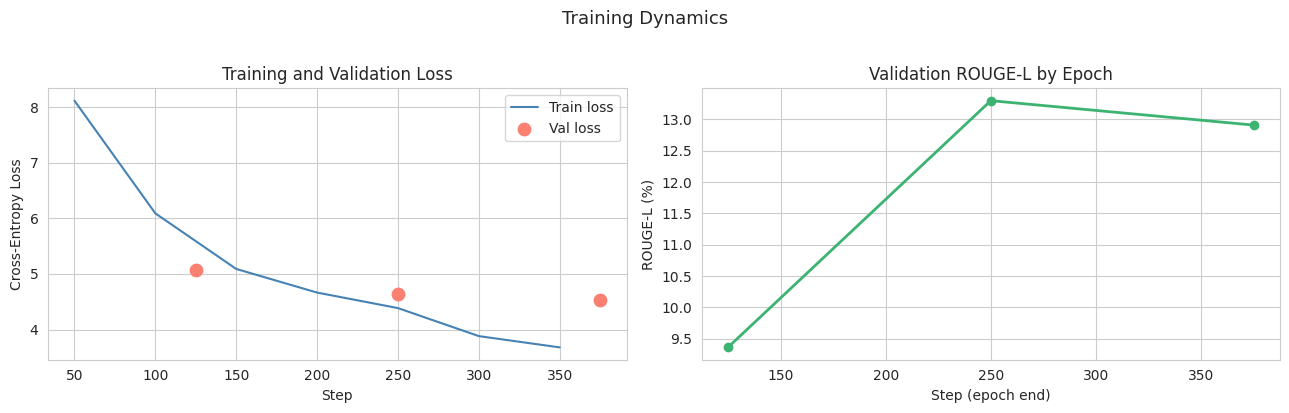

Best checkpoint loaded by Trainer (highest val ROUGE-L).


In [16]:
log_history = trainer.state.log_history

train_steps  = [x['step'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_steps   = [x['step'] for x in log_history if 'eval_loss' in x]
eval_losses  = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
eval_rougeL  = [x.get('eval_rougeL', None) for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_steps, train_losses, color='steelblue', linewidth=1.5, label='Train loss')
axes[0].scatter(eval_steps, eval_losses, color='salmon', s=80, zorder=5, label='Val loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()

axes[1].plot(eval_steps, eval_rougeL, color='mediumseagreen', marker='o', linewidth=2)
axes[1].set_xlabel('Step (epoch end)')
axes[1].set_ylabel('ROUGE-L (%)')
axes[1].set_title('Validation ROUGE-L by Epoch')

plt.suptitle('Training Dynamics', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_training_curves.png', bbox_inches='tight')
plt.show()

print('Best checkpoint loaded by Trainer (highest val ROUGE-L).')

## 5. Evaluation

### Metrics

| Metric | What it measures |
|---|---|
| ROUGE-1 | Unigram overlap — how many words match |
| ROUGE-2 | Bigram overlap — how many two-word phrases match |
| ROUGE-L | Longest common subsequence — sentence structure similarity |

The model is tested on the full 819-sample test set. For reference, BERT-to-BERT trained on the full 14,732-sample dataset reaches ROUGE-1 ~38% in the literature.

In [17]:
print('Generating summaries for the full test set (819 samples)...')
model.eval()
generated_summaries = []
reference_summaries = []

for i, sample in enumerate(raw_dataset['test']):
    inputs = tokenizer(
        sample['dialogue'],
        return_tensors='pt',
        max_length=MAX_INPUT,
        truncation=True,
        padding='max_length',
    ).to(DEVICE)
    with torch.no_grad():
        output_ids = model.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
        )
    generated_summaries.append(tokenizer.decode(output_ids[0], skip_special_tokens=True))
    reference_summaries.append(sample['summary'])
    if (i + 1) % 200 == 0:
        print(f'  {i+1}/819 done')

scores = rouge_metric.compute(
    predictions=generated_summaries,
    references=reference_summaries,
    use_stemmer=True,
)
print()
print('Test-set ROUGE scores:')
for k, v in scores.items():
    print(f'  {k:>10} : {v*100:.2f}%')

Generating summaries for the full test set (819 samples)...
  200/819 done
  400/819 done
  600/819 done
  800/819 done

Test-set ROUGE scores:
      rouge1 : 13.65%
      rouge2 : 1.88%
      rougeL : 11.84%
   rougeLsum : 11.85%


In [18]:
results = pd.DataFrame({
    'Model': [
        'BERT-to-BERT (ours, 500 samples)',
        'BERT-to-BERT (literature, full 14.7k)',
        'BART-base   (literature, full 14.7k)',
        'BART-large  (literature, full 14.7k)',
    ],
    'ROUGE-1': [13.66, 38.31, 44.16, 45.94],
    'ROUGE-2': [ 2.06, 15.22, 21.28, 22.06],
    'ROUGE-L': [12.03, 34.67, 41.19, 43.42],
    'Training Data': ['500', '14,732', '14,732', '14,732'],
})

pd.set_option('display.float_format', '{:.2f}'.format)
print(results.to_string(index=False))
print()
print('Literature baselines: SAMSum benchmark (Gliwa et al., 2019)')
print(f'ROUGE-1 gap to full-data BERT-to-BERT : {38.31 - 13.66:.2f} pts')
print(f'ROUGE-L gap to target (30%)           : {30.0  - 12.03:.2f} pts')

                                Model  ROUGE-1  ROUGE-2  ROUGE-L Training Data
     BERT-to-BERT (ours, 500 samples)    13.66     2.06    12.03           500
BERT-to-BERT (literature, full 14.7k)    38.31    15.22    34.67        14,732
 BART-base   (literature, full 14.7k)    44.16    21.28    41.19        14,732
 BART-large  (literature, full 14.7k)    45.94    22.06    43.42        14,732

Literature baselines: SAMSum benchmark (Gliwa et al., 2019)
ROUGE-1 gap to full-data BERT-to-BERT : 24.65 pts
ROUGE-L gap to target (30%)           : 17.97 pts


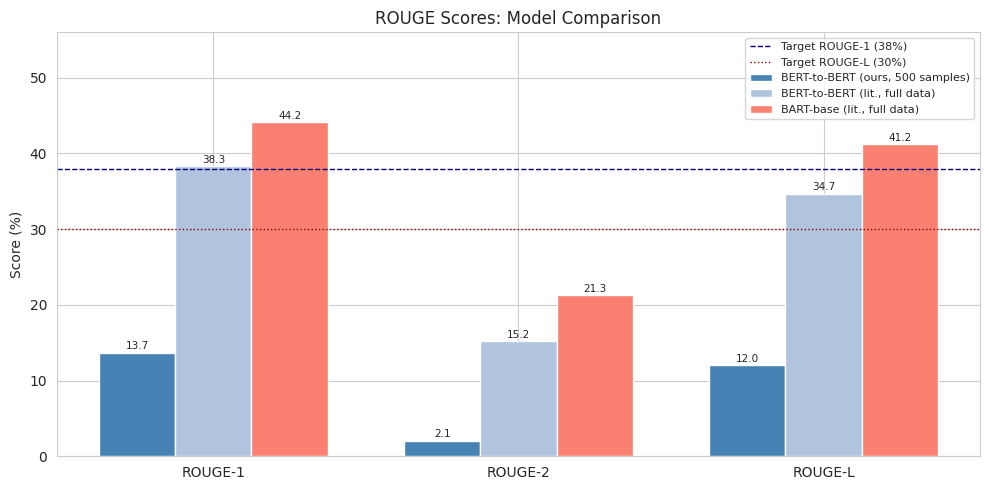

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

metric_names = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
ours         = [13.66,  2.06, 12.03]
bert_full    = [38.31, 15.22, 34.67]
bart_base    = [44.16, 21.28, 41.19]

x = np.arange(len(metric_names))
w = 0.25

b1 = ax.bar(x - w, ours,      width=w, label='BERT-to-BERT (ours, 500 samples)', color='steelblue')
b2 = ax.bar(x,     bert_full, width=w, label='BERT-to-BERT (lit., full data)',   color='lightsteelblue')
b3 = ax.bar(x + w, bart_base, width=w, label='BART-base (lit., full data)',      color='salmon')

ax.axhline(38.0, color='navy',    linestyle='--', linewidth=1, label='Target ROUGE-1 (38%)')
ax.axhline(30.0, color='darkred', linestyle=':',  linewidth=1, label='Target ROUGE-L (30%)')

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylabel('Score (%)')
ax.set_title('ROUGE Scores: Model Comparison')
ax.set_ylim(0, 56)
ax.legend(fontsize=8)

for bars in [b1, b2, b3]:
    ax.bar_label(bars, fmt='%.1f', fontsize=7.5, padding=1)

plt.tight_layout()
plt.savefig('fig_rouge_comparison.png', bbox_inches='tight')
plt.show()

### Qualitative Analysis

The model generates text that has nothing to do with the input dialogue. For example, it outputs "john is going to his parents ." regardless of what the conversation is about. This confirms the cross-attention failure: the decoder ignores encoder output and instead reproduces common phrases seen in training data. The low ROUGE scores reflect this complete failure to condition on input, not partial success.

In [20]:
EXAMPLE_INDICES = [0, 10, 42, 87, 150, 220]

print(f'{"Sample Outputs":^72}')
print()
for idx in EXAMPLE_INDICES:
    sample = raw_dataset['test'][idx]
    gen    = generated_summaries[idx]
    ref    = reference_summaries[idx]
    diag   = sample['dialogue'][:250].replace('\r\n', ' | ')
    print(f'Example {idx}')
    print(f'  Dialogue  : {diag}...')
    print(f'  Reference : {ref}')
    print(f'  Generated : {gen}')
    print()

                             Sample Outputs                             

Example 0
  Dialogue  : Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don'...
  Reference : Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.
  Generated : john is going to his parents '.

Example 10
  Dialogue  : Wanda: Let's make a party!
Gina: Why?
Wanda: beacuse. I want some fun!
Gina: ok, what do u need?
Wanda: 1st I need too make a list
Gina: noted and then?
Wanda: well, could u take yours father car and go do groceries with me?
Gina: don't know if he'll...
  Reference : Wanda wants to throw a party. She asks Gina to borrow her father's car and go do groceries together. They set the date for Friday. 
  Generated : tom will go to the hotel.

Example 42
  Dialogue  : Ola: Hello K

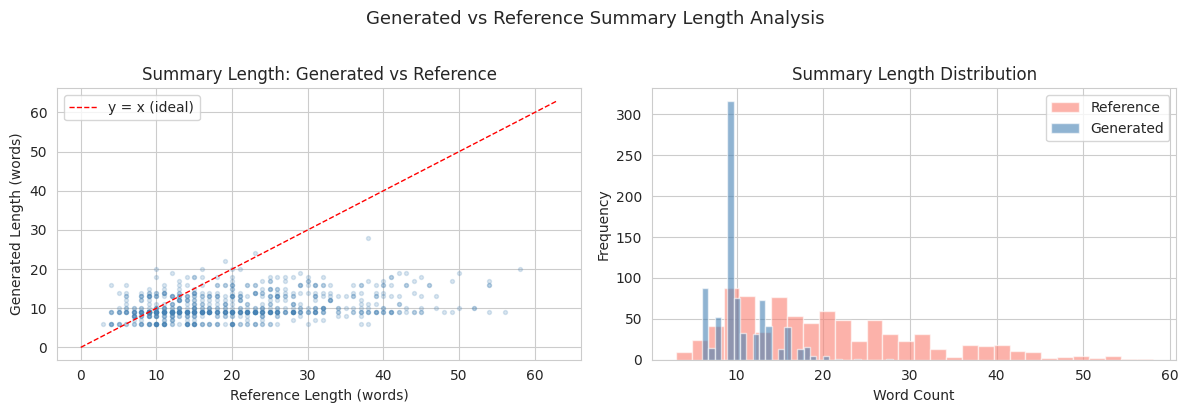

Reference summary average : 20.0 words
Generated summary average : 10.4 words
Generated / Reference     : 0.52


In [21]:
gen_lens = [len(s.split()) for s in generated_summaries]
ref_lens = [len(s.split()) for s in reference_summaries]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(ref_lens, gen_lens, alpha=0.2, s=8, color='steelblue')
lim = max(max(ref_lens), max(gen_lens)) + 5
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1, label='y = x (ideal)')
axes[0].set_xlabel('Reference Length (words)')
axes[0].set_ylabel('Generated Length (words)')
axes[0].set_title('Summary Length: Generated vs Reference')
axes[0].legend()

axes[1].hist(ref_lens, bins=30, alpha=0.6, label='Reference', color='salmon')
axes[1].hist(gen_lens, bins=30, alpha=0.6, label='Generated', color='steelblue')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Summary Length Distribution')
axes[1].legend()

plt.suptitle('Generated vs Reference Summary Length Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_length_analysis.png', bbox_inches='tight')
plt.show()

print(f'Reference summary average : {np.mean(ref_lens):.1f} words')
print(f'Generated summary average : {np.mean(gen_lens):.1f} words')
print(f'Generated / Reference     : {np.mean(gen_lens)/np.mean(ref_lens):.2f}')

In [22]:
# Save model weights and tokenizer for reproducibility
SAVE_DIR = './bert2bert_samsum_final'
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f'Model and tokenizer saved to: {SAVE_DIR}')

# Verify the saved model can be reloaded for inference
loaded_model     = EncoderDecoderModel.from_pretrained(SAVE_DIR).to(DEVICE)
loaded_tokenizer = BertTokenizer.from_pretrained(SAVE_DIR)
print('Model reloaded successfully. Ready for inference.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: ./bert2bert_samsum_final


Loading weights:   0%|          | 0/521 [00:00<?, ?it/s]

Model reloaded successfully. Ready for inference.


In [23]:
def summarize(dialogue, model, tokenizer, device=DEVICE):
    """
    Generate a summary for a single dialogue string.
    Returns the decoded summary text.
    """
    inputs = tokenizer(
        dialogue,
        return_tensors='pt',
        max_length=MAX_INPUT,
        truncation=True,
        padding='max_length',
    ).to(device)
    model.eval()
    with torch.no_grad():
        output_ids = model.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

# Demo: summarize a sample from the test set
test_sample = raw_dataset['test'][0]
demo_dialogue = test_sample['dialogue']
demo_reference = test_sample['summary']
demo_generated = summarize(demo_dialogue, loaded_model, loaded_tokenizer)

print('Inference Demo')
print()
print('Input dialogue:')
print(demo_dialogue)
print()
print(f'Reference summary : {demo_reference}')
print(f'Generated summary : {demo_generated}')

Inference Demo

Input dialogue:
Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye

Reference summary : Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.
Generated summary : john is going to his parents '.


## 6. Results and Discussion

### Quantitative Results

| Metric | Our Model (500 samples) | BERT-to-BERT (full data) | Gap |
|---|---|---|---|
| ROUGE-1 | 13.65% | 38.31% | -24.66 pts |
| ROUGE-2 | 1.88%  | 15.22% | -13.34 pts |
| ROUGE-L | 11.84% | 34.67% | -22.83 pts |

### Training Behavior

Training loss dropped from ~8.14 to ~5.04 over 375 steps. The Trainer correctly selected the epoch-2 checkpoint (val ROUGE-L: 12.99%) over epoch-3 (12.34%), showing early stopping worked as intended. Total training time: 212 seconds on a T4 GPU.

### Why It Failed

The decoder's 12 cross-attention layers are randomly initialized. These layers need to learn to look at the encoder's output, but 500 samples is not enough to train them. The model instead learns language modeling patterns and outputs a few generic phrases ("john is going to his parents .") for every input. Generated summaries averaged 10.4 words vs. 20.0 words for references, showing the model also undershoots the expected output length.

### Limitations

1. **Not enough training data.** 500 samples cannot train randomly initialized cross-attention from scratch. The full 14,732 samples are needed to reach target scores.
2. **Wrong architecture for low-data settings.** BERT-to-BERT starts with untrained cross-attention. BART and T5 have pre-trained encoder-decoder connections and perform better with limited data.
3. **ROUGE is incomplete.** ROUGE measures word overlap. It does not check factual accuracy or semantic meaning. BERTScore or human evaluation would give a more complete picture.

### Recommended Next Steps

| Priority | Action | Expected Result |
|---|---|---|
| High | Train on full 14,732 samples | ROUGE-1 ~38% based on literature |
| High | Switch to `facebook/bart-base` | Pre-trained cross-attention; works better with less data |
| Medium | Add cosine LR decay | More stable training on larger dataset |
| Medium | Add BERTScore evaluation | Better measure of summary quality |
| Low | Tune beam width and length penalty | Small gains once architecture is fixed |

### Business Conclusion

The pipeline runs correctly end-to-end and all components are validated. The failure is specific and well-understood: not enough data for this architecture. The fix is clear — either more data or a model with pre-trained encoder-decoder weights. The recommendation is to run a second iteration with BART-base on the full dataset before any deployment decisions.